# Content Promotion Decision System
### Balancing Engagement and Safety in Content Promotion

In earlier steps, we built models to estimate:

- How **engaging** a piece of content is likely to be
-  How likely it is to be **unsafe** or unsuitable

This notebook focuses on the next step, the decision: *given an engagement and safety score, which content should spend be put behind to be promoted?*

This is not just a modelling problem, it’s a decision problem. We need to:

1. Maximise engagement
2. Minimise risk
3. Operate within practical constraints (e.g. marketing budget, limited promotion slots, review capacity and cost)

In practice, these objectives are often in tension:

- Some of the most engaging content is also the riskiest
- Filtering too aggressively reduces performance
- Being too permissive increases exposure to unsafe content

👉 This notebook explores how to balance these trade-offs in a simple, realistic decision system.


---

🎯 **Goal**: Translate engagement and safety model outputs into a clear, practical content promotion decision system.

**Approach**:

- Use existing model outputs - high engagement and unsafe probabilities
- Apply a **safety filter** to exclude unsafe and hold borderline content
- Rank remaining (safe) content by predicted engagement
- Select content to promote based on a fixed **promotion capacity (~25%)**
- Evaluate trade-offs

---

### Executive Summary

This notebook defines a simple decision system for content promotion using predicted engagement and safety scores. Content is first filtered for safety, then ranked by engagement, with promotion limited to a fixed proportion of posts (~25%).

Rather than relying on fixed thresholds, the system uses ranking to meet capacity constraints, resulting in an effective engagement threshold (~0.59 in this case). This highlights how promotion decisions are shaped by both model outputs and external constraints such as safety requirements and available content.

---

## Framing the Decision System

This system simulates how a brand might select content for promotion in marketing channels.

The goal is to maximise engagement while ensuring that promoted content is safe for a broad audience.

Two constraints are introduced:

1. Only a limited proportion of content can be promoted due to budget constraints (approx. 25%)
2. Unsafe or borderline content should not be surfaced without review

To reflect this, the system is designed as a two-stage pipeline: safety filtering followed by engagement-based selection.


### 0. Imports and Data

In [9]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

from sentence_transformers import SentenceTransformer

In [2]:
# Load dataset
shortlist_df = pd.read_parquet("../data/processed/shortlist_combined_df.parquet")

In [3]:
shortlist_df.columns.tolist()

['id',
 'title',
 'score',
 'upvote_ratio',
 'num_comments',
 'created_utc',
 'subreddit',
 'subscribers',
 'permalink',
 'url',
 'domain',
 'num_awards',
 'num_crossposts',
 'crosspost_subreddits',
 'post_type',
 'is_nsfw',
 'is_bot',
 'is_megathread',
 'body',
 'filename',
 'score_scaled',
 'comments_scaled',
 'engagement',
 'high_engagement',
 'engagement_rank',
 'title_length',
 'has_question',
 'has_exclamation',
 'has_number']

## 1. Rebuild both models

Each post is scored by two models that provide two different signals:

* **Engagement score** → likelihood of high performance
* **Safety score** → likelihood of being unsafe

Note that these are probabilistic outputs, not ground truth. The decision system must translate these into actions.


In [4]:
# Recreate features for both models
embed = SentenceTransformer("all-MiniLM-L6-v2")

titles = shortlist_df["title"].to_list()
title_embeddings = embed.encode(titles, show_progress_bar=True)

embed_dim = title_embeddings.shape[1]
embed_columns = [f"title_embeddings_{i}" for i in range(embed_dim)]
embed_df = pd.DataFrame(title_embeddings, columns=embed_columns, index=shortlist_df.index)

X = pd.concat([embed_df, shortlist_df[["subreddit"]]], axis=1)

# Create safety target variable
shortlist_df["unsafe"] = shortlist_df["is_nsfw"].astype(int)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/217 [00:00<?, ?it/s]

In [5]:
# Define targets
y_engagement = shortlist_df["high_engagement"]
y_safety = shortlist_df["unsafe"]

# Create splits for both models
from sklearn.model_selection import train_test_split

X_eng_train, X_eng_test, y_eng_train, y_eng_test = train_test_split(
    X,
    y_engagement,
    test_size=0.2,
    random_state=42
)

X_safe_train, X_safe_test, y_safe_train, y_safe_test = train_test_split(
    X,
    y_safety,
    test_size=0.2,
    random_state=42
)

# Rebuild pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("subreddit_ohe", OneHotEncoder(handle_unknown="ignore"), ["subreddit"]),
        ("embedding_pass", "passthrough", embed_columns)
    ]
)

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
])

from sklearn.base import clone

engagement_model = clone(pipeline)
safety_model = clone(pipeline)

engagement_model.fit(X_eng_train, y_eng_train)
safety_model.fit(X_safe_train, y_safe_train)

# Generate both probabilities
engagement_probs = engagement_model.predict_proba(X)[:, 1]
safety_probs = safety_model.predict_proba(X)[:, 1]

In [6]:
print(engagement_probs[:5])
print(safety_probs[:5])

[0.9287667  0.8348478  0.96292416 0.81634355 0.82406487]
[0.37005856 0.93363795 0.13666504 0.07605078 0.1041647 ]


## 2. Decision Table

Both models now operate on the same feature set, making it possible to score each post on expected engagement and safety risk within a single decision table.


In [7]:
# Create a combined decision table
decision_df = pd.DataFrame({
    "title": shortlist_df["title"],
    "subreddit": shortlist_df["subreddit"],
    "engagement_prob": engagement_probs,
    "safety_prob": safety_probs
})

decision_df.head()

,title,subreddit,engagement_prob,safety_prob
0,"People who haven't pooped in 2019 yet, why are...",askreddit,0.928767,0.370059
1,How would you feel about Reddit adding 3 NSFW ...,askreddit,0.834848,0.933638
2,Would you watch a show where a billionaire CEO...,askreddit,0.962924,0.136665
3,"What if God came down one day and said ""It's p...",askreddit,0.816344,0.076051
4,How would you feel about a feature where if so...,askreddit,0.824065,0.104165


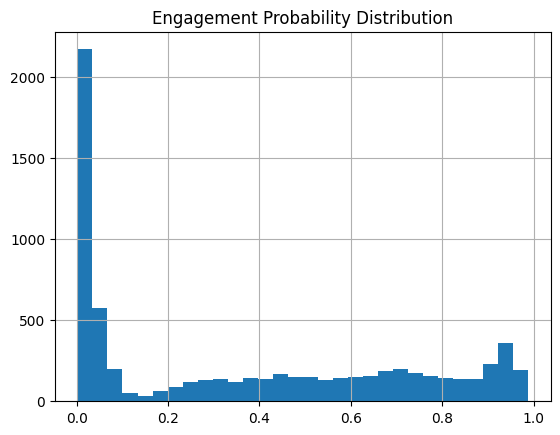

In [10]:
decision_df["engagement_prob"].hist(bins=30)

plt.title("Engagement Probability Distribution")
plt.show()

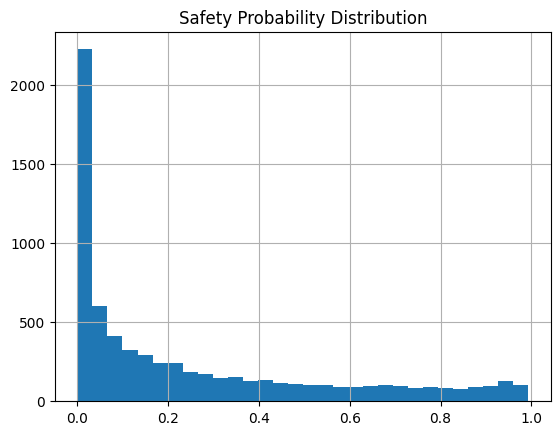

In [12]:
decision_df["safety_prob"].hist(bins=30)

plt.title("Safety Probability Distribution")
plt.show()

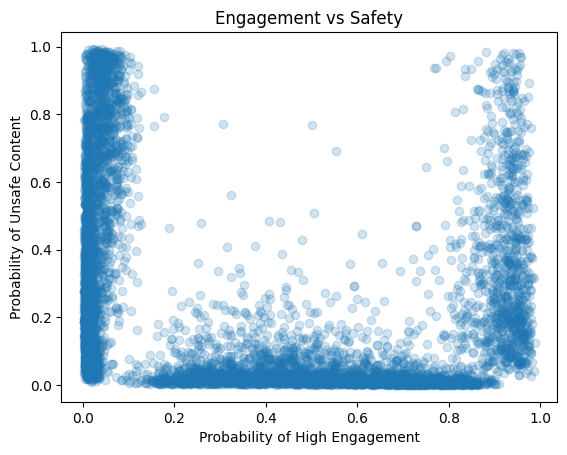

In [11]:
import matplotlib.pyplot as plt

plt.scatter(
    decision_df["engagement_prob"],
    decision_df["safety_prob"],
    alpha=0.2
)

plt.xlabel("Probability of High Engagement")
plt.ylabel("Probability of Unsafe Content")
plt.title("Engagement vs Safety")
plt.show()

#### 🙋‍♀️ Observed trade-off

Plotting engagement against safety reveals a key pattern:
* most content is safe but low engagement
* a smaller subset is high engagement **and higher risk**

This highlights a key challenge: optimising purely for engagement would surface some of the riskiest content. As such, a decision system must explicitly balance these competing signals rather than treating them independently.

## 3. Desiging the Decision System

Content evaluation is performed as a two-stage process to combine safety and engagement decisions.

**1. Safety filter**

* Unsafe → excluded
* Borderline → held for review
* Safe → allowed through

**2. Engagement ranking**

* Safe content is ranked by predicted engagement
* Only the top ~25% is promoted (budget constraint)

This ensures that high engagement alone is not sufficient for promotion - content must first meet safety standards before being considered for amplification.

Thresholds should be selected based on the trade-off between recall and operational cost. In particular, the safety threshold is chosen to maximise recall for unsafe content while keeping the proportion of content requiring human review within a manageable range.

### Safety thresholds

In [14]:
# --- Revisit safety thresholds ---

# Get unsafe probabilities for test set
safety_probs = safety_model.predict_proba(X_safe_test)[:, 1]

# Range of thresholds from 0 to 1
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for number in thresholds:
    safety_pred_threshold = (safety_probs >= number).astype(int)
    print(f"\nThreshold: {number}")
    print(classification_report(y_safe_test, safety_pred_threshold))
    print("Confusion Matrix:")
    print(confusion_matrix(y_safe_test, safety_pred_threshold))


Threshold: 0.1
              precision    recall  f1-score   support

           0       0.99      0.51      0.68      1280
           1       0.14      0.95      0.25       108

    accuracy                           0.55      1388
   macro avg       0.57      0.73      0.46      1388
weighted avg       0.93      0.55      0.64      1388

Confusion Matrix:
[[655 625]
 [  5 103]]

Threshold: 0.2
              precision    recall  f1-score   support

           0       0.99      0.64      0.78      1280
           1       0.18      0.91      0.30       108

    accuracy                           0.66      1388
   macro avg       0.58      0.78      0.54      1388
weighted avg       0.92      0.66      0.74      1388

Confusion Matrix:
[[823 457]
 [ 10  98]]

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.98      0.73      0.84      1280
           1       0.21      0.85      0.34       108

    accuracy                           0.74      138

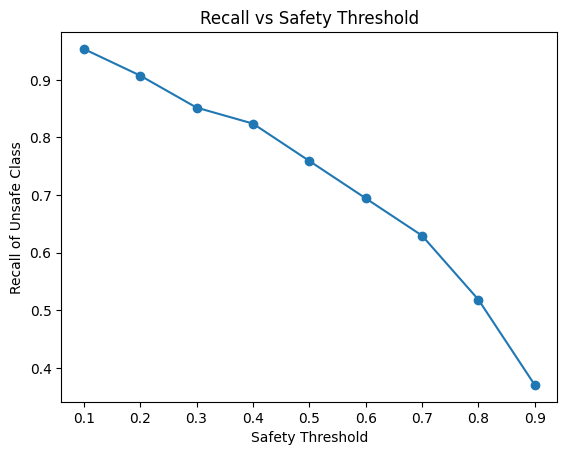

In [ ]:
# Plot recall vs threshold
recalls = []
for number in thresholds:
    safety_pred_threshold = (safety_probs >= number).astype(int)
    report = classification_report(y_safe_test, safety_pred_threshold, output_dict=True)
    recalls.append(report["1"]["recall"])

plt.plot(thresholds, recalls, marker="o")
plt.xlabel("Safety Threshold")
plt.ylabel("Recall of Unsafe Class")
plt.title("Recall vs Safety Threshold")
plt.show()

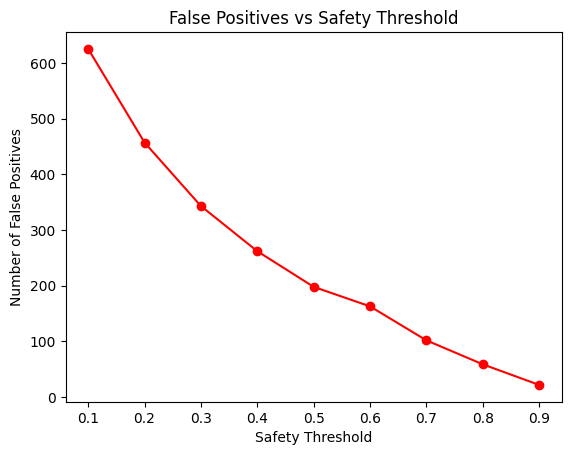

In [16]:
# Plot false positives (cost) vs threshold
false_positives = []

for number in thresholds:
    safety_pred_threshold = (safety_probs >= number).astype(int)
    cm = confusion_matrix(y_safe_test, safety_pred_threshold)
    false_positives.append(cm[0][1])

plt.plot(thresholds, false_positives, marker="o", color="red")
plt.xlabel("Safety Threshold")
plt.ylabel("Number of False Positives")
plt.title("False Positives vs Safety Threshold")
plt.show()

#### 🙋‍♀️ Selecting safety thresholds

- **Review threshold = 0.3**
- **Block threshold = 0.7**

Thresholds are selected based on the trade-off between recall and false positives. A threshold of 0.3 is chosen for review, as it provides strong recall (~0.85) without a sharp increase in false positives. Lower thresholds improve recall further, but at a disproportionate cost.

A higher threshold of 0.7 is used to identify high-confidence unsafe content for automatic blocking. This block threshold is deliberately conservative and could be adjusted depending on risk appetite and moderation capacity. Lowering it would reduce the chance of unsafe content slipping through, but would increase the risk of incorrectly blocking safe content.

In [ ]:
# Define safety buckets
def assign_safety_bucket(prob):
    if prob < 0.3:
        return "Safe"
    elif prob < 0.7:
        return "Review"
    else:
        return "Block"

# Apply safety buckets to the decision dataframe
decision_df["safety_bucket"] = decision_df["safety_prob"].apply(assign_safety_bucket)

# Check distribution of safety buckets:
# We want to see plenty of "Safe" content available for promotion
decision_df[["title", "safety_prob", "safety_bucket"]].value_counts("safety_bucket")

safety_bucket
Safe      4713
Review    1384
Block      839
Name: count, dtype: int64

### Selecting content for promotion

For the purpose of a more realistic model, we assume budget constraints mean ~25% of total posts can be promoted, and that content must first pass the safety filter above.

Here, the remaining safe content is ranked by predicted engagement, and the top posts selected for promotion within budget.

This means the engagement threshold is not fixed in advance - it emerges from the ranking step.


In [ ]:
# Calculate target post volume for promotion (~25% of total posts)
target_volume = int(len(decision_df) * 0.25)

# Filter to only "Safe" content and sort by engagement probability
safe_candidates = decision_df[decision_df["safety_bucket"] == "Safe"].copy()

promoted_df = safe_candidates.sort_values(
    "engagement_prob",
    ascending=False
    ).head(target_volume)

promoted_df.shape

(1734, 5)

The engagement threshold is not fixed in advance, but can be derived from the selected posts as the lowest score in the promoted set.

This is useful for interpretation and monitoring, but is not required for the decision process itself.


In [31]:
effective_engagement_threshold = promoted_df["engagement_prob"].min()

effective_engagement_threshold

np.float64(0.592215489231964)

👆 In this run, selecting the top ~25% of safe content results in an effective engagement threshold of **~0.59**.

This represents the minimum predicted engagement score required for a post to be promoted under current constraints.

If this is considered too low (e.g. promoted content underperforms in practice), the team has a few levers:

* reduce promotion volume (e.g. top 20% instead of 25%)
* tighten the safety filter
* or expand the candidate pool (e.g. include additional subreddits) to maintain quality while meeting volume targets

In practice, this highlights that content quality is not just a function of model thresholds, but also of **where content is sourced from**.

### Estimating expected performance

While engagement scores are used to rank content, they can also provide a rough estimate of expected return.

For a given set of promoted posts:

* the **average probability** reflects overall quality
* the **sum of probabilities** approximates the expected number of high-performing posts

This provides a simple way to compare different promotion strategies under the same budget.


## Conclusion

This notebook moves from model outputs to actual decisions, showing how engagement and safety signals can be combined into a simple, practical promotion system.

In practice, this results in:

* Unsafe content being excluded early
* Borderline content accumulating in a review queue
* High-performing safe content dominating promoted slots

A key takeaway is that thresholds alone do not define system behaviour. Promotion volume, safety constraints, and the underlying content pool all play an important role in determining outcomes. For example, the effective engagement threshold (~0.59 in this case) emerges from these combined factors rather than being set directly.

If this threshold is considered too low, improving outcomes is not just a matter of tuning model cut-offs - it may require adjusting promotion volume, refining safety rules, or expanding the pool of candidate content.

There are, of course, limitations:

* Model outputs are probabilistic and imperfect
* Engagement is based on proxy signals rather than true business outcomes
* Thresholds are static, whereas real systems would adapt over time

Despite this, the system demonstrates how competing objectives - **performance** and **safety** - can be translated into clear, operational decisions.
